# 🎛️ Hyperparameter Tuning in Prophet

## 1. Why Tune?
Prophet has sensible defaults, but every dataset is unique.
* Some datasets are **stiff** (trends change slowly).
* Some are **flexible** (trends change quickly).
* Some have **multiplicative seasonality** (seasonal waves get bigger as the trend grows).

## 2. The Key Parameters
We usually tune these three inputs:

1.  **`changepoint_prior_scale` (Default: 0.05)**
    * Determines how flexible the trend is.
    * *High (0.5):* Very flexible, fits every bump (Risk: Overfitting).
    * *Low (0.001):* Very stiff, basically a straight line (Risk: Underfitting).

2.  **`seasonality_prior_scale` (Default: 10.0)**
    * Determines how strong the seasonality is compared to the trend.
    * *High:* The seasonal waves can be huge.
    * *Low:* The seasonal waves are dampened (shrunk).

3.  **`seasonality_mode` (Default: 'additive')**
    * **'additive':** The seasonal wave is constant size (e.g., +50 units every December).
    * **'multiplicative':** The seasonal wave is a percentage (e.g., +10% every December). If the trend doubles, the wave height doubles.

## 3. The Grid Search Strategy
Since we cannot mathematically calculate the perfect values (like in ARIMA), we use **Grid Search**:
1.  Define a list of values to try for each parameter.
2.  Train a model for every combination.
3.  Run Cross-Validation on each model.
4.  Pick the combination with the lowest RMSE or MAPE.

#### 1) Importing Necessary Libraries:

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

from sklearn.model_selection import ParameterGrid

import warnings
warnings.filterwarnings('ignore')

#### 2) Loading Data:

In [8]:
df = pd.read_csv('airline_passengers.csv')

In [9]:
df.head()

,Month,Thousands of Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [10]:
df.shape

(144, 2)

##### Restructuring Dataframe for Prophet needs:

In [11]:
df.columns = ['ds', 'y']
df['ds'] = pd.to_datetime(df['ds'])
df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      144 non-null    datetime64[ns]
 1   y       144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


##### Visualizing Data:

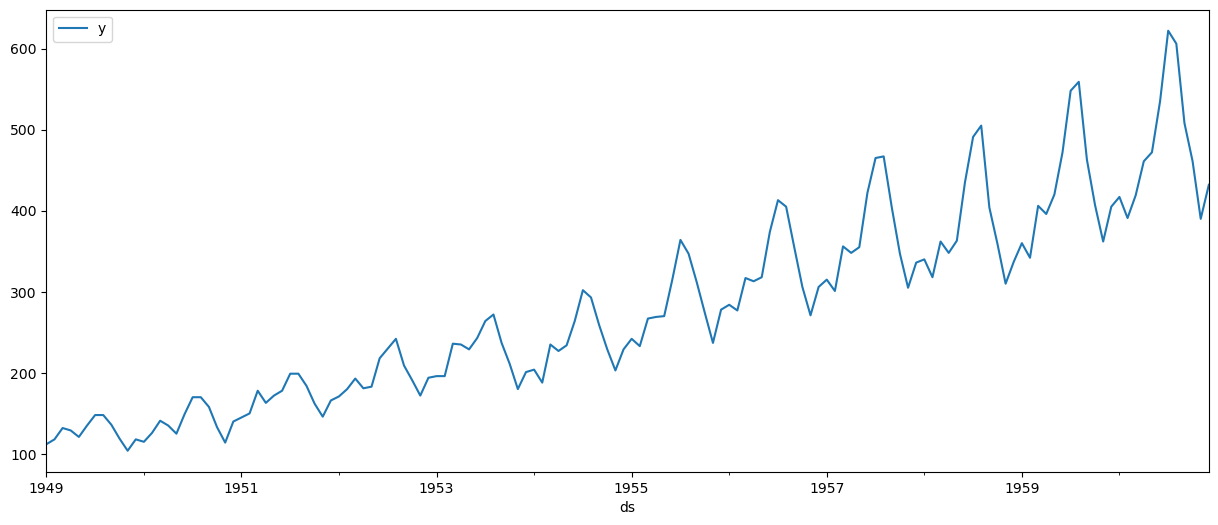

In [13]:
df.plot(x= 'ds', y= 'y', figsize= (15,6))
plt.show()

#### 3) Grid Search to find Best Parameters using Prophet:

In [16]:
# Definig Grid:

params_grid = {
    'changepoint_prior_scale' : [0.001, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative']
}

grid = ParameterGrid(param_grid= params_grid)

print(len(grid))

24


In [20]:
# Grid Search:

cnt = 0
results = []

for p in grid:
    cnt += 1
    print(f"Testing combination {cnt}/{len(grid)}: {p}")

    # Prophet Model with Current Parameters:
    m = Prophet(
        changepoint_prior_scale= p['changepoint_prior_scale'],
        seasonality_prior_scale= p['seasonality_prior_scale'],
        seasonality_mode= p['seasonality_mode']
    )

    # Fitting The Model:
    m.fit(df)

    try:
        # Cross Validation:
        # dataset length is ~12 years (144 months)
        # initial='3650 days' -> Train on first 10 years
        # period='180 days'   -> Shift forward by 6 months
        # horizon='365 days'  -> Predict the next 1 year
        df_cv = cross_validation(model= m,
                                initial= '3650 days',
                                period= '180 days',
                                horizon= '365 days',
                                parallel= 'processes',
                                disable_tqdm= True)

        # Calculating Metrics:
        df_p = performance_metrics(df= df_cv,
                                  rolling_window= 1)

        # Storing Results:
        results.append([p, df_p['rmse'].values[0], df_p['mape'].values[0]])

    except Exception as e:
        print(f"CV failed for {p}: {e}")

21:07:38 - cmdstanpy - INFO - Chain [1] start processing


Testing combination 1/24: {'changepoint_prior_scale': 0.001, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 0.01}


21:07:38 - cmdstanpy - INFO - Chain [1] done processing
21:07:38 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
21:07:39 - cmdstanpy - INFO - Chain [1] start processing
21:07:39 - cmdstanpy - INFO - Chain [1] done processing
21:07:45 - cmdstanpy - INFO - Chain [1] start processing
21:07:45 - cmdstanpy - INFO - Chain [1] done processing


Testing combination 2/24: {'changepoint_prior_scale': 0.001, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 1.0}


21:07:45 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
21:07:45 - cmdstanpy - INFO - Chain [1] start processing
21:07:45 - cmdstanpy - INFO - Chain [1] done processing
21:07:52 - cmdstanpy - INFO - Chain [1] start processing


...

21:09:38 - cmdstanpy - INFO - Chain [1] done processing
21:09:43 - cmdstanpy - INFO - Chain [1] start processing


Testing combination 23/24: {'changepoint_prior_scale': 0.5, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 1.0}


21:09:43 - cmdstanpy - INFO - Chain [1] done processing
21:09:49 - cmdstanpy - INFO - Chain [1] start processing


Testing combination 24/24: {'changepoint_prior_scale': 0.5, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 10.0}


21:09:50 - cmdstanpy - INFO - Chain [1] done processing


In [21]:
#Analyzing Results:

tuning_results = pd.DataFrame(results, columns=['Parameters', 'RMSE', 'MAPE'])

In [22]:
# Sorting by lowest MAPE:

tuning_results = tuning_results.sort_values(by='MAPE').reset_index(drop=True)

In [23]:
print("\n--- TOP 3 PARAMETER COMBINATIONS ---")
print(tuning_results.head(3))


--- TOP 3 PARAMETER COMBINATIONS ---
                                          Parameters       RMSE      MAPE
0  {'changepoint_prior_scale': 0.05, 'seasonality...  27.180772  0.051697
1  {'changepoint_prior_scale': 0.05, 'seasonality...  27.490990  0.052272
2  {'changepoint_prior_scale': 0.05, 'seasonality...  32.015015  0.052525


In [25]:
# Results:

tuning_results

,Parameters,RMSE,MAPE
0,"{'changepoint_prior_scale': 0.05, 'seasonality...",27.180772,0.051697
1,"{'changepoint_prior_scale': 0.05, 'seasonality...",27.490990,0.052272
2,"{'changepoint_prior_scale': 0.05, 'seasonality...",32.015015,0.052525
3,"{'changepoint_prior_scale': 0.1, 'seasonality_...",34.417005,0.055153
4,"{'changepoint_prior_scale': 0.5, 'seasonality_...",29.652863,0.055752
5,"{'changepoint_prior_scale': 0.5, 'seasonality_...",29.758934,0.055899
6,"{'changepoint_prior_scale': 0.1, 'seasonality_...",29.679025,0.056443
7,"{'changepoint_prior_scale': 0.1, 'seasonality_...",30.052328,0.057148
8,"{'changepoint_prior_scale': 0.5, 'seasonality_...",34.873728,0.059053
9,"{'changepoint_prior_scale': 0.05, 'seasonality...",40.263958,0.062298
